# DPL CPU Models — Evaluation Notebook

Loads the three previously saved CPU-friendly models (TF-IDF + LinearSVC, TF-IDF + Logistic
Regression, DistilBERT) from the `models/` directory and re-runs the comparison evaluation
**without retraining**.

## Structure
1. Imports
2. Load dataset (test split)
3. Load saved models
4. Compare all models
5. Per-class F1 comparison
6. Inference helper

## 1. Imports

In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
warnings.filterwarnings("ignore")

from sklearn.metrics import accuracy_score, f1_score, classification_report as sklearn_cr
print("Imports OK")

Imports OK


## 2. Load Dataset (Test Split)

In [2]:
from sklearn.preprocessing import LabelEncoder

DATASETS_DIR = "../datasets"

train_df = pd.read_csv(f"{DATASETS_DIR}/dpl_train.csv")
test_df  = pd.read_csv(f"{DATASETS_DIR}/dpl_test.csv")

le = LabelEncoder()
le.fit(sorted(train_df["dpl_tag"].unique()))
NUM_LABELS = len(le.classes_)

id2label = {i: c for i, c in enumerate(le.classes_)}
label2id = {c: i for i, c in enumerate(le.classes_)}

X_test = test_df["description"].tolist()
y_test = le.transform(test_df["dpl_tag"])

print(f"Test rows : {len(test_df):,}")
print(f"Classes   : {NUM_LABELS}")

Test rows : 2,272
Classes   : 76


## 3. Load Saved Models

In [3]:
_PATHS = {
    "svc": "../models/tfidf_svc/model.joblib",
    "lr":  "../models/tfidf_lr/model.joblib",
    "distilbert_model":  "../models/distilbert/model",
    "distilbert_labels": "../models/distilbert/label_classes.json",
}
_missing = [p for k, p in _PATHS.items()
            if k != "distilbert_model" and not os.path.isfile(p)]
if not os.path.isdir(_PATHS["distilbert_model"]):
    _missing.append(_PATHS["distilbert_model"] + " (directory)")
if _missing:
    print("ERROR: Missing model files:"); [print(f"  {p}") for p in _missing]
    raise FileNotFoundError("Run the training notebook first.")

svc_pipeline = joblib.load(_PATHS["svc"]); print(f"SVC     loaded from {_PATHS['svc']}")
lr_pipeline  = joblib.load(_PATHS["lr"]);  print(f"LogReg  loaded from {_PATHS['lr']}")

# DistilBERT
from transformers import pipeline as hf_pipeline
db_classifier = hf_pipeline(
    "text-classification",
    model=_PATHS["distilbert_model"],
    tokenizer=_PATHS["distilbert_model"],
    device=-1,  # CPU
    top_k=None,
)
print(f"DistilBERT loaded from {_PATHS['distilbert_model']}")

SVC     loaded from ../models/tfidf_svc/model.joblib
LogReg  loaded from ../models/tfidf_lr/model.joblib


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT loaded from ../models/distilbert/model


In [4]:
# Compute predictions for SVC and LR
svc_preds  = svc_pipeline.predict(X_test)
lr_preds   = lr_pipeline.predict(X_test)
lr_probs   = lr_pipeline.predict_proba(X_test)

svc_acc = accuracy_score(y_test, svc_preds)
svc_f1  = f1_score(y_test, svc_preds, average="weighted", zero_division=0)
lr_acc  = accuracy_score(y_test, lr_preds)
lr_f1   = f1_score(y_test, lr_preds,  average="weighted", zero_division=0)
print(f"LinearSVC  — Acc: {svc_acc:.4f}  Weighted F1: {svc_f1:.4f}")
print(f"LogReg     — Acc: {lr_acc:.4f}  Weighted F1: {lr_f1:.4f}")

# DistilBERT batch prediction (slower on CPU)
print("Running DistilBERT on test set (this may take a few minutes on CPU)...")
db_batch = db_classifier(X_test, batch_size=32, truncation=True, max_length=128)
db_preds = np.array([le.transform([max(r, key=lambda x: x["score"])["label"]])[0] for r in db_batch])
db_acc   = accuracy_score(y_test, db_preds)
db_f1    = f1_score(y_test, db_preds, average="weighted", zero_division=0)
print(f"DistilBERT — Acc: {db_acc:.4f}  Weighted F1: {db_f1:.4f}")

LinearSVC  — Acc: 0.9996  Weighted F1: 0.9996
LogReg     — Acc: 0.9996  Weighted F1: 0.9996
Running DistilBERT on test set (this may take a few minutes on CPU)...
DistilBERT — Acc: 1.0000  Weighted F1: 1.0000


## 4. Compare All Models

                    Accuracy  Weighted F1
Model                                    
TF-IDF + LinearSVC    0.9996       0.9996
TF-IDF + LogReg       0.9996       0.9996
DistilBERT            1.0000       1.0000


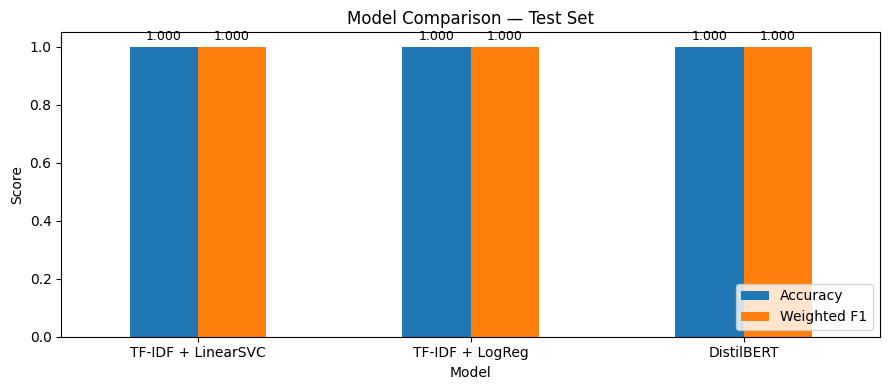

In [5]:
results = {
    "TF-IDF + LinearSVC":  {"accuracy": svc_acc, "f1_weighted": svc_f1, "preds": svc_preds},
    "TF-IDF + LogReg":     {"accuracy": lr_acc,  "f1_weighted": lr_f1,  "preds": lr_preds},
    "DistilBERT":          {"accuracy": db_acc,  "f1_weighted": db_f1,  "preds": db_preds},
}

results_df = pd.DataFrame([
    {"Model": k, "Accuracy": v["accuracy"], "Weighted F1": v["f1_weighted"]}
    for k, v in results.items()
]).set_index("Model")
print(results_df.to_string(float_format="{:.4f}".format))

fig, ax = plt.subplots(figsize=(9, 4))
results_df.plot(kind="bar", ax=ax, width=0.5, rot=0)
ax.set_ylim(0, 1.05); ax.set_title("Model Comparison — Test Set")
ax.set_ylabel("Score"); ax.legend(loc="lower right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)
plt.tight_layout(); plt.show()

## 5. Per-class F1 Comparison

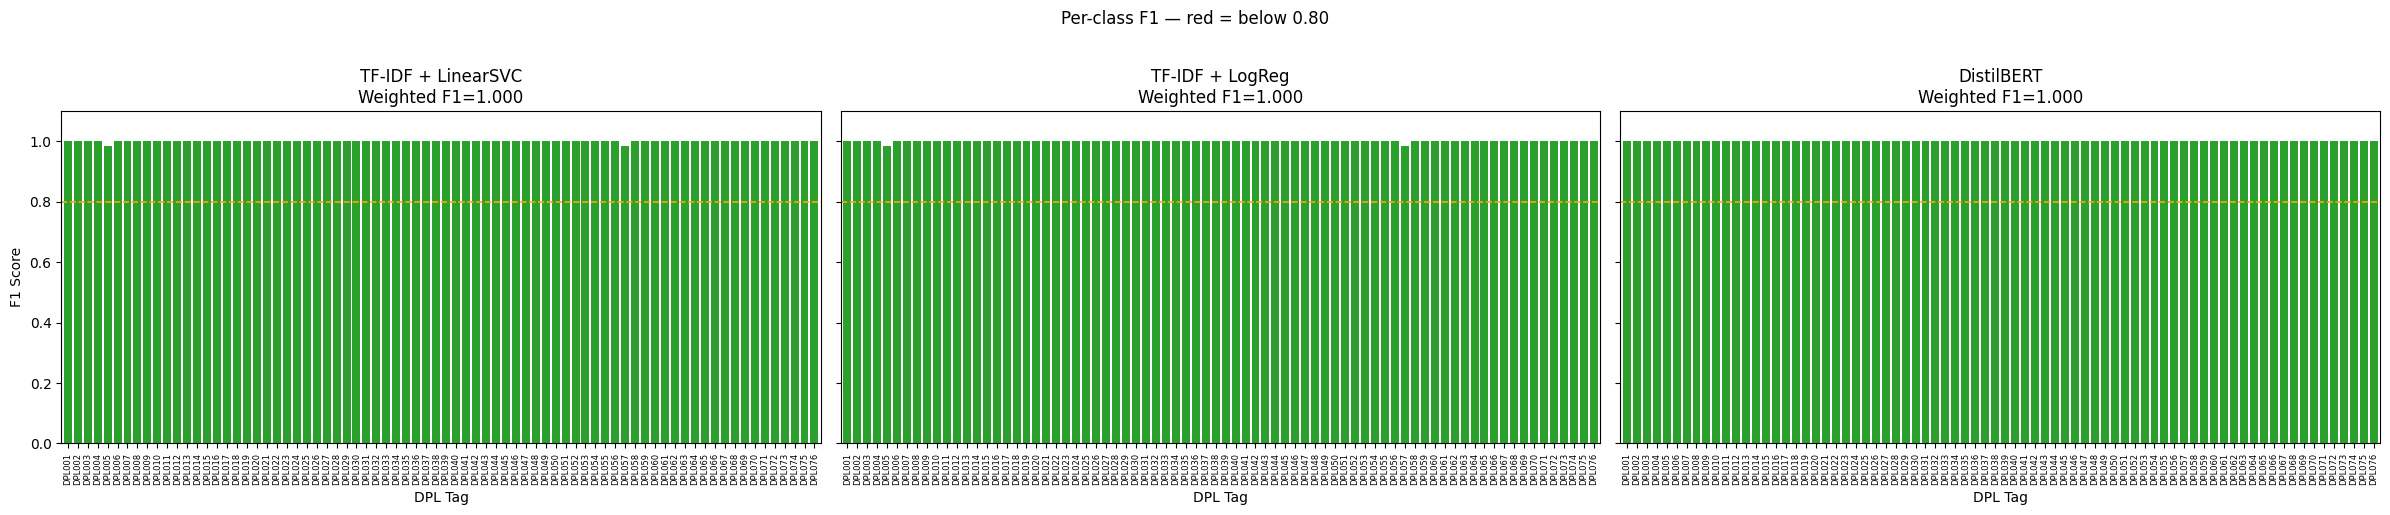

In [6]:
tag_names = le.classes_.tolist()

fig, axes = plt.subplots(1, 3, figsize=(24, 5), sharey=True)
for ax, (name, v) in zip(axes, results.items()):
    rep  = sklearn_cr(le.inverse_transform(y_test), le.inverse_transform(v["preds"]),
                      output_dict=True, zero_division=0)
    f1s  = pd.Series({t: rep[t]["f1-score"] for t in tag_names if t in rep}).sort_index()
    cols = ["#d62728" if x < 0.80 else "#2ca02c" for x in f1s.values]
    f1s.plot(kind="bar", ax=ax, color=cols, width=0.8)
    ax.axhline(0.80, color="orange", linestyle="--", linewidth=1.2)
    ax.set_title(f"{name}\nWeighted F1={v['f1_weighted']:.3f}")
    ax.set_xlabel("DPL Tag"); ax.set_ylim(0, 1.1); ax.tick_params(axis="x", labelsize=6, rotation=90)
axes[0].set_ylabel("F1 Score")
plt.suptitle("Per-class F1 — red = below 0.80", y=1.02)
plt.tight_layout(); plt.show()

## 6. Inference Helper

In [7]:
def predict_sklearn(descriptions, model_path="../models/tfidf_svc/model.joblib", top_k=3):
    pipe = joblib.load(model_path)
    with open(model_path.replace("model.joblib", "label_classes.json")) as f:
        _lmap = json.load(f)
    preds     = pipe.predict(descriptions)
    pred_tags = [_lmap["id2label"][str(p)] for p in preds]
    if hasattr(pipe.named_steps.get("clf", None), "predict_proba"):
        probs = pipe.predict_proba(descriptions)
        top_tags = [
            [(_lmap["id2label"][str(i)], float(probs[row][i]))
             for i in np.argsort(probs[row])[::-1][:top_k]]
            for row in range(len(descriptions))
        ]
    else:
        top_tags = [[(t, None)] for t in pred_tags]
    return pred_tags, top_tags

test_descs = [
    "INV-55234 – Deloitte audit services FY2025",
    "Monthly payroll – March 2026 – Finance",
    "Interest charged on HSBC overdraft – January",
    "Office rent – London HQ – April 2026",
    "FX loss on USD settlement – AP-78341",
]

print("=== TF-IDF + LinearSVC ===")
svc_tags, _ = predict_sklearn(test_descs, "../models/tfidf_svc/model.joblib")
for desc, tag in zip(test_descs, svc_tags):
    print(f"  {desc:<55} → {tag}")

print("\n=== TF-IDF + Logistic Regression (top-3) ===")
_, lr_top3 = predict_sklearn(test_descs, "../models/tfidf_lr/model.joblib", top_k=3)
for desc, top in zip(test_descs, lr_top3):
    top_str = "  |  ".join(f"{tag} ({score:.3f})" for tag, score in top)
    print(f"  {desc:<55}  {top_str}")

print("\n=== DistilBERT ===")
db_results = db_classifier(test_descs)
for desc, preds in zip(test_descs, db_results):
    top = max(preds, key=lambda x: x["score"])
    print(f"  {desc:<55} → {top['label']} ({top['score']:.3f})")

=== TF-IDF + LinearSVC ===
  INV-55234 – Deloitte audit services FY2025              → DPL003
  Monthly payroll – March 2026 – Finance                  → DPL068
  Interest charged on HSBC overdraft – January            → DPL035
  Office rent – London HQ – April 2026                    → DPL055
  FX loss on USD settlement – AP-78341                    → DPL043

=== TF-IDF + Logistic Regression (top-3) ===
  INV-55234 – Deloitte audit services FY2025               DPL003 (0.954)  |  DPL011 (0.002)  |  DPL008 (0.002)
  Monthly payroll – March 2026 – Finance                   DPL068 (0.947)  |  DPL057 (0.013)  |  DPL058 (0.005)
  Interest charged on HSBC overdraft – January             DPL035 (0.981)  |  DPL076 (0.003)  |  DPL006 (0.001)
  Office rent – London HQ – April 2026                     DPL055 (0.963)  |  DPL059 (0.003)  |  DPL029 (0.002)
  FX loss on USD settlement – AP-78341                     DPL043 (0.980)  |  DPL014 (0.003)  |  DPL022 (0.000)

=== DistilBERT ===
  INV-55234 